# 🤖 Notebook 3 — Advanced Regression Models
**Dataset:** Life Expectancy (WHO)

This notebook covers:
1. Artificial Neural Network (ANN / Keras)
2. Gradient Boosting Regressor
3. Decision Tree Regressor
4. K-Nearest Neighbors (KNN) Regressor
5. Random Forest Regressor


## 0. Setup — Load Preprocessed Data

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from warnings import filterwarnings
filterwarnings('ignore')

with open('data/splits.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Data loaded. X_train:", X_train.shape)


Data loaded. X_train: (2350, 18)


## 1. Artificial Neural Network (ANN)

In [10]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1,  activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Optional: visualize model architecture
# plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=0)
print("Training complete.")


Training complete.


In [12]:
y_predann = model.predict(X_test)

r2_ann  = r2_score(y_test, y_predann)
mse_ann = mean_squared_error(y_test, y_predann)
print(f"ANN  R² Score : {r2_ann:.4f}")
print(f"ANN  MSE      : {mse_ann:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
ANN  R² Score : 0.9315
ANN  MSE      : 5.9344


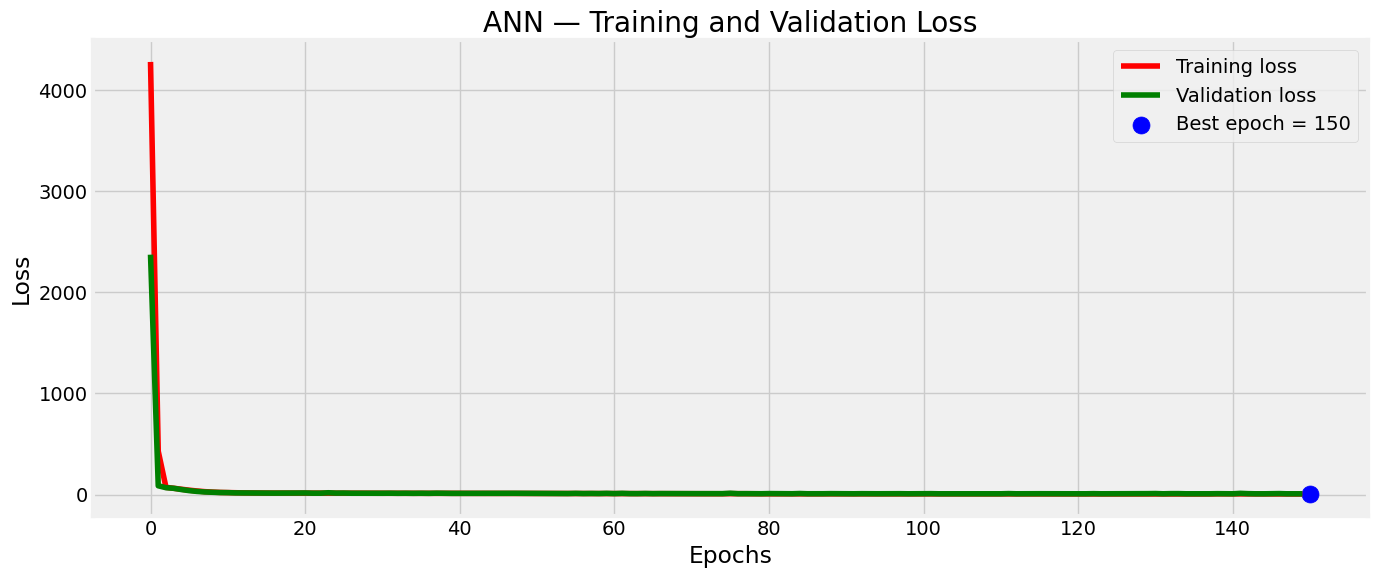

In [13]:
# Training & validation loss curves
tr_loss   = history.history['loss']
val_loss  = history.history['val_loss']
index_min = np.argmin(val_loss)

plt.figure(figsize=(14, 6))
plt.style.use('fivethirtyeight')
plt.plot(tr_loss,  'r', label='Training loss')
plt.plot(val_loss, 'g', label='Validation loss')
plt.scatter(index_min + 1, val_loss[index_min], s=150, c='blue',
            label=f'Best epoch = {index_min + 1}')
plt.title('ANN — Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Gradient Boosting Regressor

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(X_train, y_train)

print("Best Parameters:", grid_search_gb.best_params_)
best_gbr = grid_search_gb.best_estimator_


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [15]:
predictionsGB = best_gbr.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, predictionsGB):.4f}")
print(f"MSE  : {mean_squared_error(y_test, predictionsGB):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, predictionsGB)):.4f}")
print(f"R²   : {r2_score(y_test, predictionsGB):.4f}")


MAE  : 1.1370
MSE  : 2.7850
RMSE : 1.6688
R²   : 0.9679


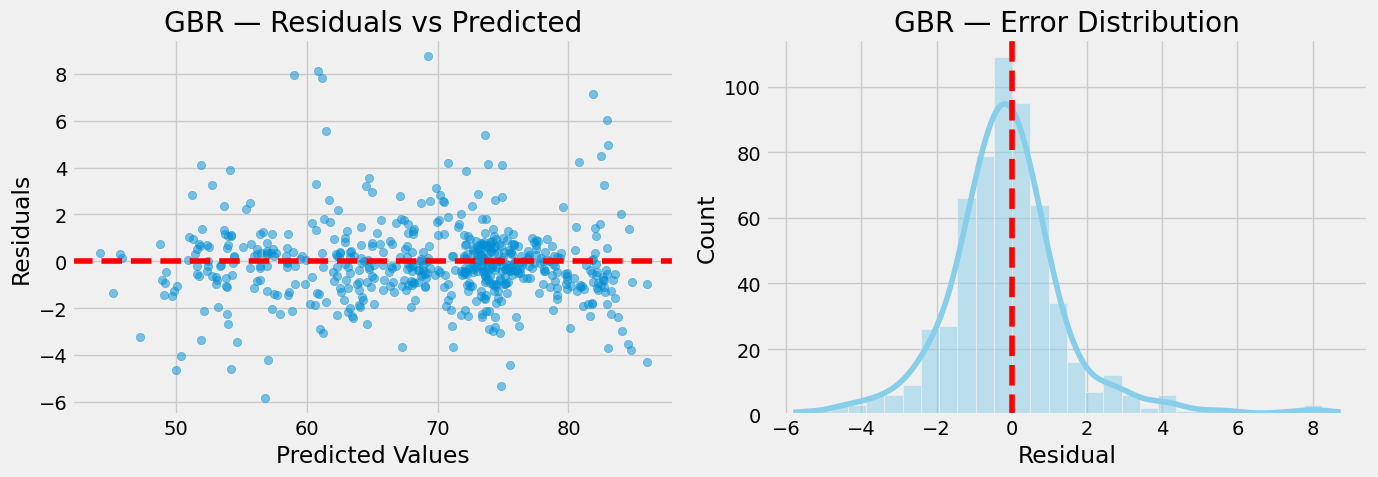

In [16]:
# Residuals plot
residuals_gb = y_test - predictionsGB

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(predictionsGB, residuals_gb, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('GBR — Residuals vs Predicted')

sns.histplot(residuals_gb, kde=True, bins=30, color='skyblue', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('GBR — Error Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()


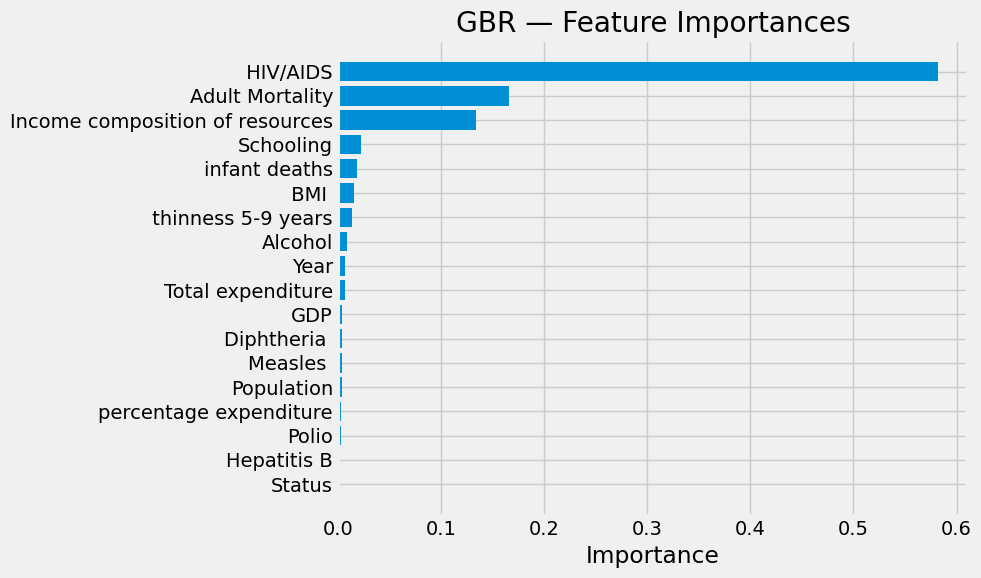

In [17]:
# Feature importances
feat_imp_gb = best_gbr.feature_importances_
indices_gb  = np.argsort(feat_imp_gb)

plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[indices_gb], feat_imp_gb[indices_gb])
plt.title('GBR — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Key finding:** HIV/AIDS and Income composition of resources are the most important
predictors — reflecting direct mortality impact and socio-economic development respectively.


## 3. Decision Tree Regressor

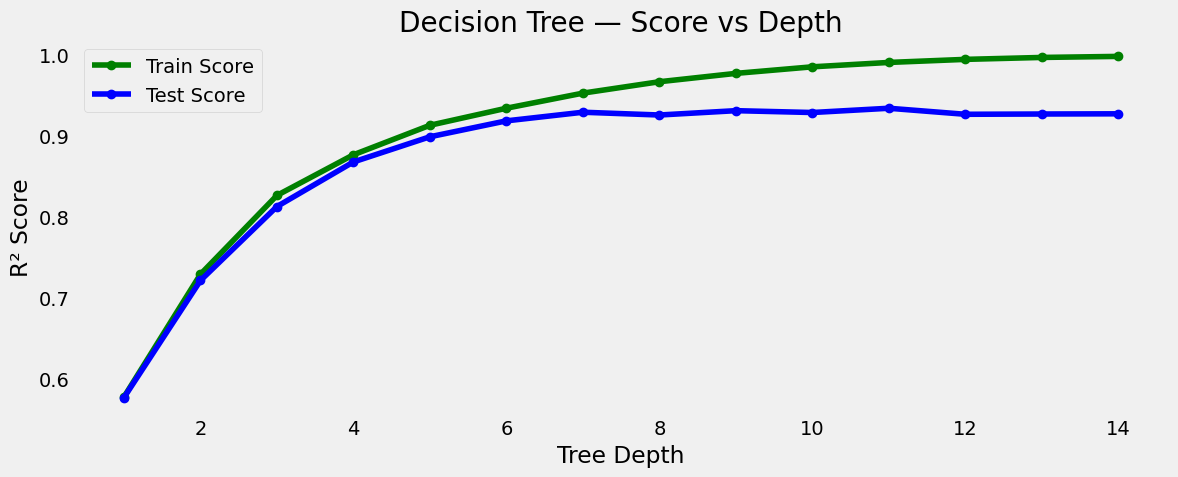

In [18]:
from sklearn.tree import DecisionTreeRegressor

dt_train_scores, dt_test_scores = [], []

for depth in range(1, 15):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=0)
    dt.fit(X_train, y_train)
    dt_train_scores.append(dt.score(X_train, y_train))
    dt_test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(12, 5))
plt.plot(range(1, 15), dt_train_scores, 'g-o', label='Train Score')
plt.plot(range(1, 15), dt_test_scores,  'b-o', label='Test Score')
plt.xlabel('Tree Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree — Score vs Depth')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Depth 6 provides the best generalisation: high scores on both sets with
a small train/test gap.


In [19]:
# GridSearchCV for best hyperparameters
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth':        range(1, 10),
    'min_samples_leaf': range(1, 10),
    'criterion':        ['squared_error', 'absolute_error', 'friedman_mse'],
    'splitter':         ['best', 'random']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=0),
    param_grid=dt_param_grid,
    return_train_score=True,
    cv=5,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print("Best DT params:", dt_grid.best_params_)


Best DT params: {'criterion': 'friedman_mse', 'max_depth': 9, 'min_samples_leaf': 6, 'splitter': 'best'}


In [20]:
best_dt = dt_grid.best_estimator_
ydt_predicted = best_dt.predict(X_test)

from sklearn.metrics import r2_score
print('Train score:{:.4f}'.format(best_dt.score(X_train, y_train)))
print('Test score: {:.4f}'.format(best_dt.score(X_test,  y_test)))
print('R²:         {:.4f}'.format(r2_score(y_test, ydt_predicted)))
print('MSE:        {:.4f}'.format(mean_squared_error(y_test, ydt_predicted)))


Train score:0.9656
Test score: 0.9264
R²:         0.9264
MSE:        6.3753


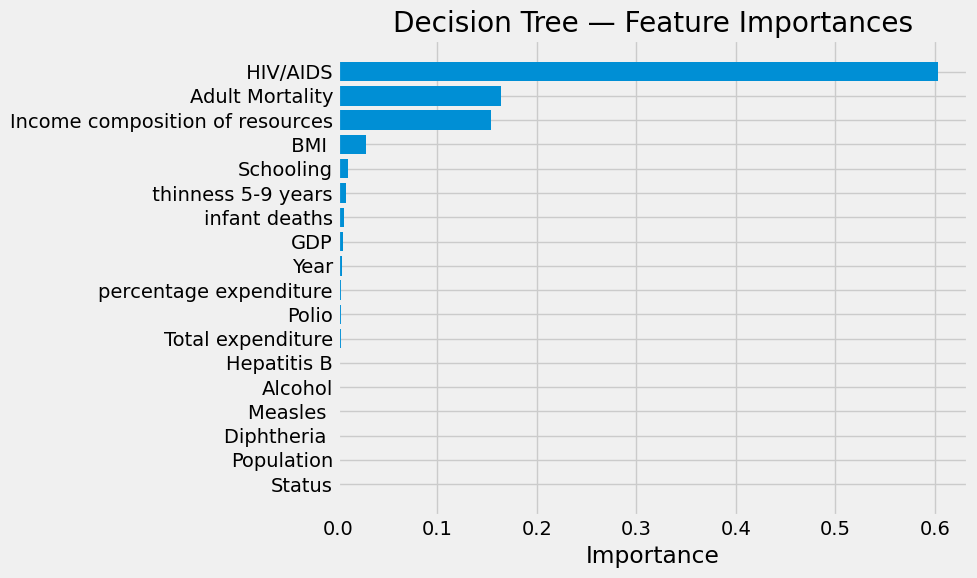

In [21]:
# Feature importances
feat_imp_dt = best_dt.feature_importances_
indices_dt  = np.argsort(feat_imp_dt)

plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[indices_dt], feat_imp_dt[indices_dt])
plt.title('Decision Tree — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 4. KNN Regressor

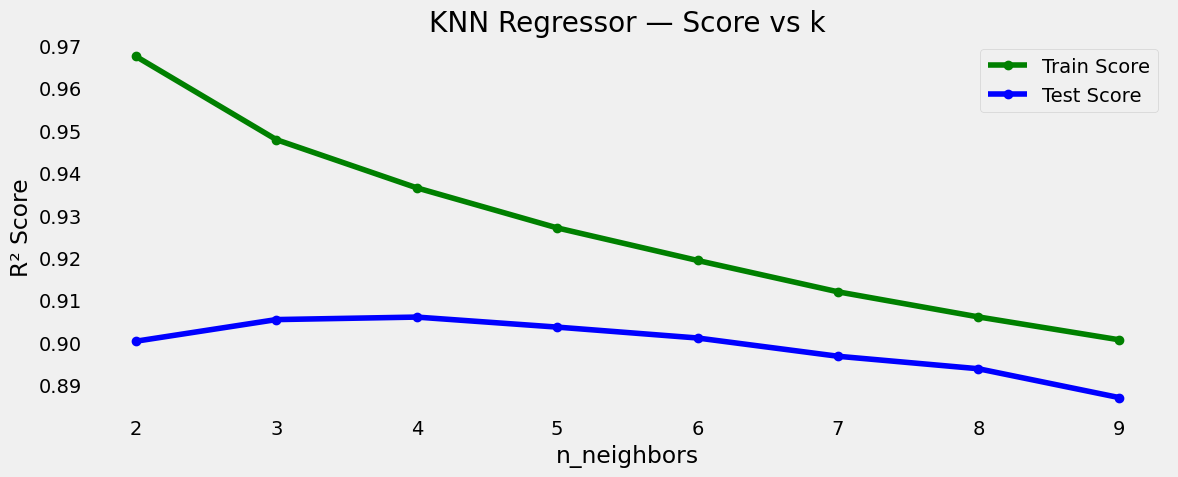

In [22]:
from sklearn.neighbors import KNeighborsRegressor

knn_train_scores, knn_test_scores = [], []

for k in range(2, 10):
    knn = KNeighborsRegressor(k)
    knn.fit(X_train, y_train)
    knn_train_scores.append(knn.score(X_train, y_train))
    knn_test_scores.append(knn.score(X_test,  y_test))

plt.figure(figsize=(12, 5))
plt.plot(range(2, 10), knn_train_scores, 'g-o', label='Train Score')
plt.plot(range(2, 10), knn_test_scores,  'b-o', label='Test Score')
plt.xlabel('n_neighbors')
plt.ylabel('R² Score')
plt.title('KNN Regressor — Score vs k')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [23]:
# GridSearchCV for best KNN hyperparameters
param_grid_knn = {
    'n_neighbors': range(2, 10),
    'weights':     ['distance', 'uniform'],
    'p':           [1, 2]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    return_train_score=True,
    cv=7
)
grid_knn.fit(X_train, y_train)
print("Best KNN params:", grid_knn.best_params_)


Best KNN params: {'n_neighbors': 4, 'p': 1, 'weights': 'distance'}


In [24]:
knn_best = grid_knn.best_estimator_
y_predknn = knn_best.predict(X_test)

print('Train score:{:.4f}'.format(knn_best.score(X_train, y_train)))
print('Test score: {:.4f}'.format(knn_best.score(X_test,  y_test)))
print('R²:         {:.4f}'.format(r2_score(y_test, y_predknn)))
print('MSE:        {:.4f}'.format(mean_squared_error(y_test, y_predknn)))


Train score:1.0000
Test score: 0.9428
R²:         0.9428
MSE:        4.9597


**Note:** KNN with `weights='distance'` can yield near-perfect train scores (potential leakage).
Evaluate test metrics carefully before choosing KNN as final model.


## 5. Random Forest Regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

param_dist_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5, 10]
}

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=param_dist_rf,
    cv=5, n_iter=10, random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train, y_train)

best_rf  = random_search_rf.best_estimator_
y_predRF = best_rf.predict(X_test)

print("Best RF params:", random_search_rf.best_params_)
print(f"RMSE: {root_mean_squared_error(y_test, y_predRF):.4f}")
print(f"R²  : {r2_score(y_test, y_predRF):.4f}")


Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
RMSE: 1.6538
R²  : 0.9684


## 6. Save All Predictions

In [26]:
import os, pickle
os.makedirs('predictions', exist_ok=True)

with open('predictions/advanced_models.pkl', 'wb') as f:
    pickle.dump({
        'y_predann':      y_predann,
        'predictionsGB':  predictionsGB,
        'ydt_predicted':  ydt_predicted,
        'y_predknn':      y_predknn,
        'y_predRF':       y_predRF,
        'y_test':         y_test
    }, f)

print("Predictions saved to predictions/advanced_models.pkl")


Predictions saved to predictions/advanced_models.pkl
